In [ ]:
"""
PROTEINS — Dense vs TopK vs Wendland
10 seeds, mean \pm or \u00B1 std curves, test boxplot
"""

import os
import random
from dataclasses import dataclass
from typing import Dict, List

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.transforms import OneHotDegree

/Users/singh_h/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [4]:
import os
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple
import torch.nn as nn

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn import global_mean_pool

from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.transforms import OneHotDegree

In [ ]:
# ---------------------------------------------------------------------
#   DensePairNet, TopKPairNet, WendlandPairNet and they must be torch.nn.Module with forward(data)-> logits (B, C)
# ---------------------------------------------------------------------


# ----------------------------
# Reproducibility
# ----------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# ----------------------------
# Wendland C2 kernel
# phi(u) = (1-u)^4_+ * (4u + 1)
# ----------------------------
def wendland_c2(u: torch.Tensor) -> torch.Tensor:
    t = (1.0 - u).clamp(min=0.0)
    return (t ** 4) * (4.0 * u + 1.0)


In [ ]:
# ----------------------------
# All-pairs shortest-path (hop) pairs for a single graph (ordered pairs i<-j)
# ----------------------------
@torch.no_grad()
def all_pairs_hop_pairs(edge_index: torch.Tensor, num_nodes: int, device=None) -> Tuple[torch.Tensor, torch.Tensor]:
    device = device or edge_index.device
    ei = edge_index.cpu()

    # undirected adjacency for hop distance
    adj = [[] for _ in range(num_nodes)]
    for u, v in ei.t().tolist():
        adj[u].append(v)
        adj[v].append(u)

    from collections import deque
    src_list, dst_list, dist_list = [], [], []

    for dst in range(num_nodes):
        dist = [-1] * num_nodes
        dist[dst] = 0
        q = deque([dst])
        while q:
            u = q.popleft()
            for v in adj[u]:
                if dist[v] == -1:
                    dist[v] = dist[u] + 1
                    q.append(v)

        # ordered pairs: dst receives from src
        for src in range(num_nodes):
            if dist[src] != -1:
                src_list.append(src)
                dst_list.append(dst)
                dist_list.append(dist[src])

    pair_index = torch.tensor([src_list, dst_list], dtype=torch.long, device=device)
    dist = torch.tensor(dist_list, dtype=torch.float32, device=device)
    return pair_index, dist


def row_normalize_alpha(alpha: torch.Tensor, dst: torch.Tensor, num_nodes: int, eps: float = 1e-8) -> torch.Tensor:
    denom = torch.zeros(num_nodes, device=alpha.device, dtype=alpha.dtype)
    denom.index_add_(0, dst, alpha * alpha)
    denom = torch.sqrt(denom + eps)
    return alpha / denom[dst]

In [6]:
# ----------------------------
# Pair mixing conv: h'_i = sum_j alpha_{ij} * (W h_j)
# ----------------------------
class PairMixConv(nn.Module):
    def __init__(self, d_in: int, d_out: int):
        super().__init__()
        self.lin = nn.Linear(d_in, d_out, bias=False)

    def forward(self, x: torch.Tensor, pair_index: torch.Tensor, alpha: torch.Tensor) -> torch.Tensor:
        src, dst = pair_index
        msg = self.lin(x[src]) * alpha.unsqueeze(-1)
        out = torch.zeros(x.size(0), msg.size(1), device=x.device, dtype=x.dtype)
        out.index_add_(0, dst, msg)
        return out

In [7]:
# ----------------------------
# Alpha builders: Dense, Wendland, TopK
# ----------------------------
class DenseAlpha(nn.Module):
    def forward(self, dist: torch.Tensor, pair_index: torch.Tensor, num_nodes: int) -> torch.Tensor:
        alpha = torch.ones_like(dist)
        _, dst = pair_index
        return row_normalize_alpha(alpha, dst, num_nodes)


class WendlandAlpha(nn.Module):
    def __init__(self, radius: int):
        super().__init__()
        self.radius = radius

    def forward(self, dist: torch.Tensor, pair_index: torch.Tensor, num_nodes: int) -> torch.Tensor:
        u = dist / max(float(self.radius), 1.0)
        alpha = wendland_c2(u)  # 0 beyond radius
        _, dst = pair_index
        return row_normalize_alpha(alpha, dst, num_nodes)
    

class TopKAlpha(nn.Module):
    """
    Learns scores for each ordered pair and selects Top-K per destination node (STE).
    K is set from a radius budget: average neighbors within r hops (like Wendland).
    """
    def __init__(self, d_node: int, hidden: int = 64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2 * d_node + 1, hidden),
            nn.GELU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x: torch.Tensor, dist: torch.Tensor, pair_index: torch.Tensor, num_nodes: int, K: int) -> torch.Tensor:
        src, dst = pair_index
        feat = torch.cat([x[src], x[dst], dist.unsqueeze(-1)], dim=-1)
        scores = self.mlp(feat).squeeze(-1)

        hard = torch.zeros_like(scores)
        for i in range(num_nodes):
            idx = (dst == i).nonzero(as_tuple=False).squeeze(-1)
            if idx.numel() == 0:
                continue
            k_i = min(K, idx.numel())
            top_idx = idx[torch.topk(scores[idx], k=k_i, largest=True).indices]
            hard[top_idx] = 1.0

        soft = torch.sigmoid(scores)
        alpha = hard + (soft - soft.detach())  # STE
        alpha = row_normalize_alpha(alpha, dst, num_nodes)
        return alpha

In [8]:
# ----------------------------
# Three models (graph classification)
# ----------------------------
class BasePairModel(nn.Module):
    def __init__(self, in_dim: int, hidden: int, num_classes: int, num_layers: int = 3, dropout: float = 0.0):
        super().__init__()
        self.enc = nn.Linear(in_dim, hidden)
        self.convs = nn.ModuleList([PairMixConv(hidden, hidden) for _ in range(num_layers)])
        self.dropout = dropout
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def mix(self, x, pair_index, dist, num_nodes):
        raise NotImplementedError

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.enc(x)

        out_x = torch.zeros_like(x)
        for g in batch.unique(sorted=True).tolist():
            mask = (batch == g)
            idx = mask.nonzero(as_tuple=False).squeeze(-1)
            xg = x[idx]

            mapping = -torch.ones(x.size(0), device=x.device, dtype=torch.long)
            mapping[idx] = torch.arange(idx.numel(), device=x.device)
            e_mask = mask[edge_index[0]] & mask[edge_index[1]]
            eg = mapping[edge_index[:, e_mask]]

            pair_index, dist = all_pairs_hop_pairs(eg, idx.numel(), device=x.device)

            hg = xg
            for conv in self.convs:
                alpha = self.mix(hg, pair_index, dist, idx.numel())
                hg = F.gelu(conv(hg, pair_index, alpha))
                hg = F.dropout(hg, p=self.dropout, training=self.training)

            out_x[idx] = hg

        g_emb = global_mean_pool(out_x, batch)
        return self.head(g_emb)


In [9]:
class DensePairNet(BasePairModel):
    def __init__(self, in_dim, hidden, num_classes, num_layers=3, dropout=0.0):
        super().__init__(in_dim, hidden, num_classes, num_layers, dropout)
        self.alpha = DenseAlpha()

    def mix(self, x, pair_index, dist, num_nodes):
        return self.alpha(dist, pair_index, num_nodes)

In [10]:
class WendlandPairNet(BasePairModel):
    def __init__(self, in_dim, hidden, num_classes, radius=2, num_layers=3, dropout=0.0):
        super().__init__(in_dim, hidden, num_classes, num_layers, dropout)
        self.alpha = WendlandAlpha(radius=radius)

    def mix(self, x, pair_index, dist, num_nodes):
        return self.alpha(dist, pair_index, num_nodes)

In [11]:
class TopKPairNet(BasePairModel):
    def __init__(self, in_dim, hidden, num_classes, radius_for_budget=2, num_layers=3, dropout=0.0):
        super().__init__(in_dim, hidden, num_classes, num_layers, dropout)
        self.alpha = TopKAlpha(d_node=hidden)
        self.radius_for_budget = radius_for_budget

    @torch.no_grad()
    def _budget_K(self, dist: torch.Tensor, num_nodes: int) -> int:
        r = float(self.radius_for_budget)
        within = (dist <= r).float()
        K = int(within.sum().item() / max(num_nodes, 1))  # avg per dst node
        return max(K, 1)

    def mix(self, x, pair_index, dist, num_nodes):
        K = self._budget_K(dist, num_nodes)
        return self.alpha(x, dist, pair_index, num_nodes, K=K)

In [12]:
# ------------------------
# Train config
# ------------------------
@dataclass
class TrainCfg:
    epochs: int = 150
    batch_size: int = 64
    lr: float = 3e-4
    weight_decay: float = 1e-4
    dropout: float = 0.2
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

In [13]:
# ------------------------
# Split
# ------------------------
def split_dataset(ds, seed=0):
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(len(ds), generator=g).tolist()
    n = len(ds)
    n_train = int(0.8 * n)
    n_val = int(0.1 * n)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return ds[train_idx], ds[val_idx], ds[test_idx]

In [14]:
# ------------------------
# Eval
# ------------------------
@torch.no_grad()
def eval_acc(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for data in loader:
        data = data.to(device)
        logits = model(data)
        pred = logits.argmax(dim=-1)
        y = data.y.view(-1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / max(total, 1)


@torch.no_grad()
def eval_loss(model, loader, device):
    model.eval()
    total_loss, total_n = 0.0, 0
    for data in loader:
        data = data.to(device)
        logits = model(data)
        y = data.y.view(-1)
        loss = F.cross_entropy(logits, y, reduction="sum")
        total_loss += loss.item()
        total_n += y.numel()
    return total_loss / max(total_n, 1)

In [15]:
# ------------------------
# Training loop
# ------------------------
def train_one(model, train_loader, val_loader, cfg):
    model = model.to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val = -1
    best_state = None

    for epoch in range(cfg.epochs):
        model.train()
        for data in train_loader:
            data = data.to(cfg.device)
            logits = model(data)
            loss = F.cross_entropy(logits, data.y.view(-1))
            opt.zero_grad()
            loss.backward()
            opt.step()

        tr_loss = eval_loss(model, train_loader, cfg.device)
        va_loss = eval_loss(model, val_loader, cfg.device)
        tr_acc = eval_acc(model, train_loader, cfg.device)
        va_acc = eval_acc(model, val_loader, cfg.device)

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["train_acc"].append(tr_acc)
        hist["val_acc"].append(va_acc)

        if va_acc > best_val:
            best_val = va_acc
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, hist

In [ ]:
# ------------------------
# Training loop
# ------------------------
def train_one(model, train_loader, val_loader, cfg):
    model = model.to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val = -1
    best_state = None

    for epoch in range(cfg.epochs):
        model.train()
        for data in train_loader:
            data = data.to(cfg.device)
            logits = model(data)
            loss = F.cross_entropy(logits, data.y.view(-1))
            opt.zero_grad()
            loss.backward()
            opt.step()

        tr_loss = eval_loss(model, train_loader, cfg.device)
        va_loss = eval_loss(model, val_loader, cfg.device)
        tr_acc = eval_acc(model, train_loader, cfg.device)
        va_acc = eval_acc(model, val_loader, cfg.device)

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["train_acc"].append(tr_acc)
        hist["val_acc"].append(va_acc)

        if va_acc > best_val:
            best_val = va_acc
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, hist


# ------------------------
# Plot mean \pm std
# ------------------------
def plot_mean_std(curves_by_model, key_train, key_val, ylabel, title):
    plt.figure(figsize=(10, 5), dpi=150)

    for name, hists in curves_by_model.items():
        A_tr = np.array([h[key_train] for h in hists])
        A_va = np.array([h[key_val] for h in hists])

        m_tr, s_tr = A_tr.mean(0), A_tr.std(0)
        m_va, s_va = A_va.mean(0), A_va.std(0)

        epochs = np.arange(1, len(m_tr) + 1)

        plt.plot(epochs, m_tr, label=f"{name} train")
        plt.fill_between(epochs, m_tr - s_tr, m_tr + s_tr, alpha=0.15)

        plt.plot(epochs, m_va, linestyle="--", label=f"{name} val")
        plt.fill_between(epochs, m_va - s_va, m_va + s_va, alpha=0.15)

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Dataset: PROTEINS(1113)
Graphs: 1113

Seed: 0
Dense test acc: 0.7411
TopK test acc: 0.7500
Wendland test acc: 0.7679

Seed: 1
Dense test acc: 0.7500
TopK test acc: 0.7054
Wendland test acc: 0.6875

Seed: 2
Dense test acc: 0.8214
TopK test acc: 0.7857
Wendland test acc: 0.7500

Seed: 3
Dense test acc: 0.7411
TopK test acc: 0.6696
Wendland test acc: 0.7411

Seed: 4
Dense test acc: 0.7054
TopK test acc: 0.7054
Wendland test acc: 0.6696

Seed: 5
Dense test acc: 0.7768
TopK test acc: 0.7589
Wendland test acc: 0.7679

Seed: 6
Dense test acc: 0.8214
TopK test acc: 0.7589
Wendland test acc: 0.7768

Seed: 7
Dense test acc: 0.8125
TopK test acc: 0.7946
Wendland test acc: 0.7411

Seed: 8
Dense test acc: 0.6875
TopK test acc: 0.7232
Wendland test acc: 0.6786

Seed: 9
Dense test acc: 0.7946
TopK test acc: 0.7589
Wendland test acc: 0.7500


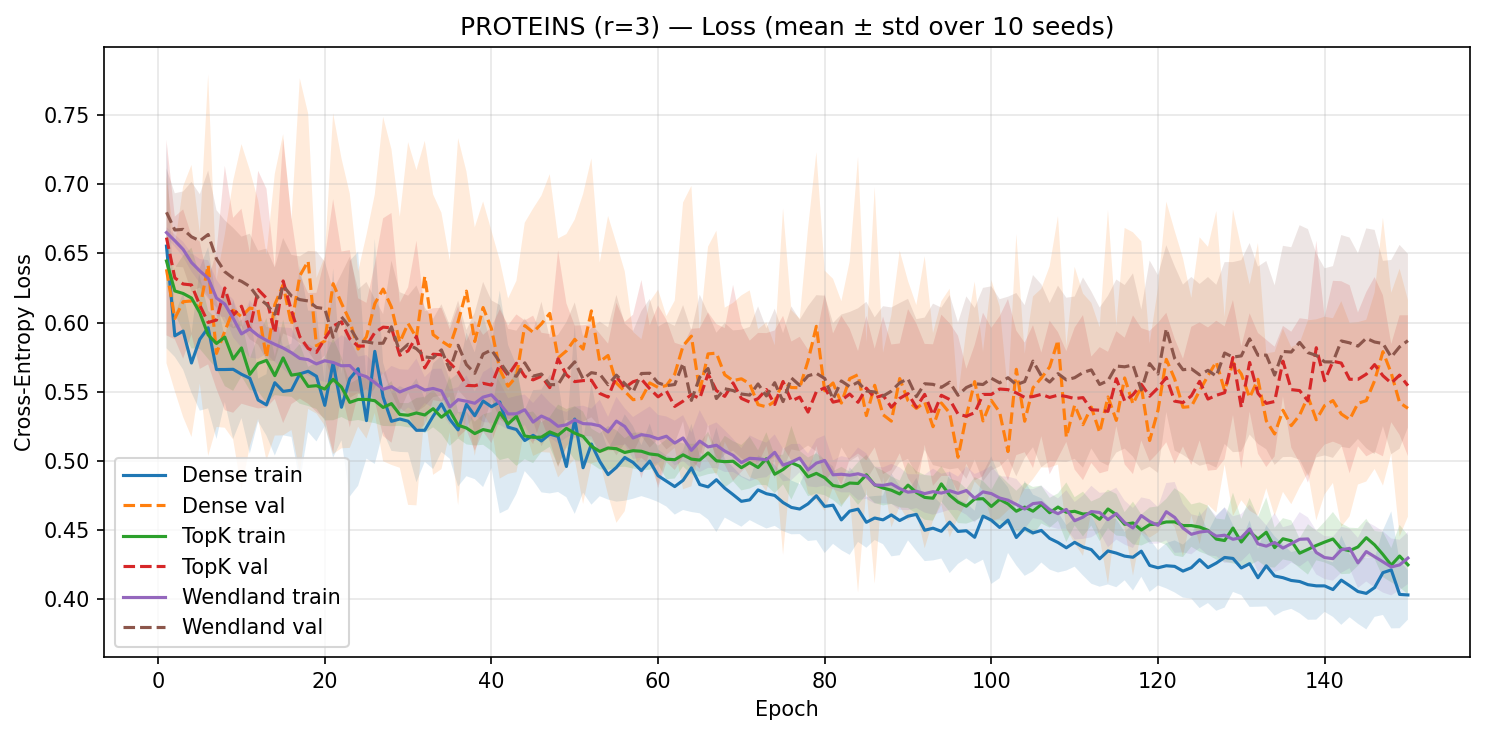

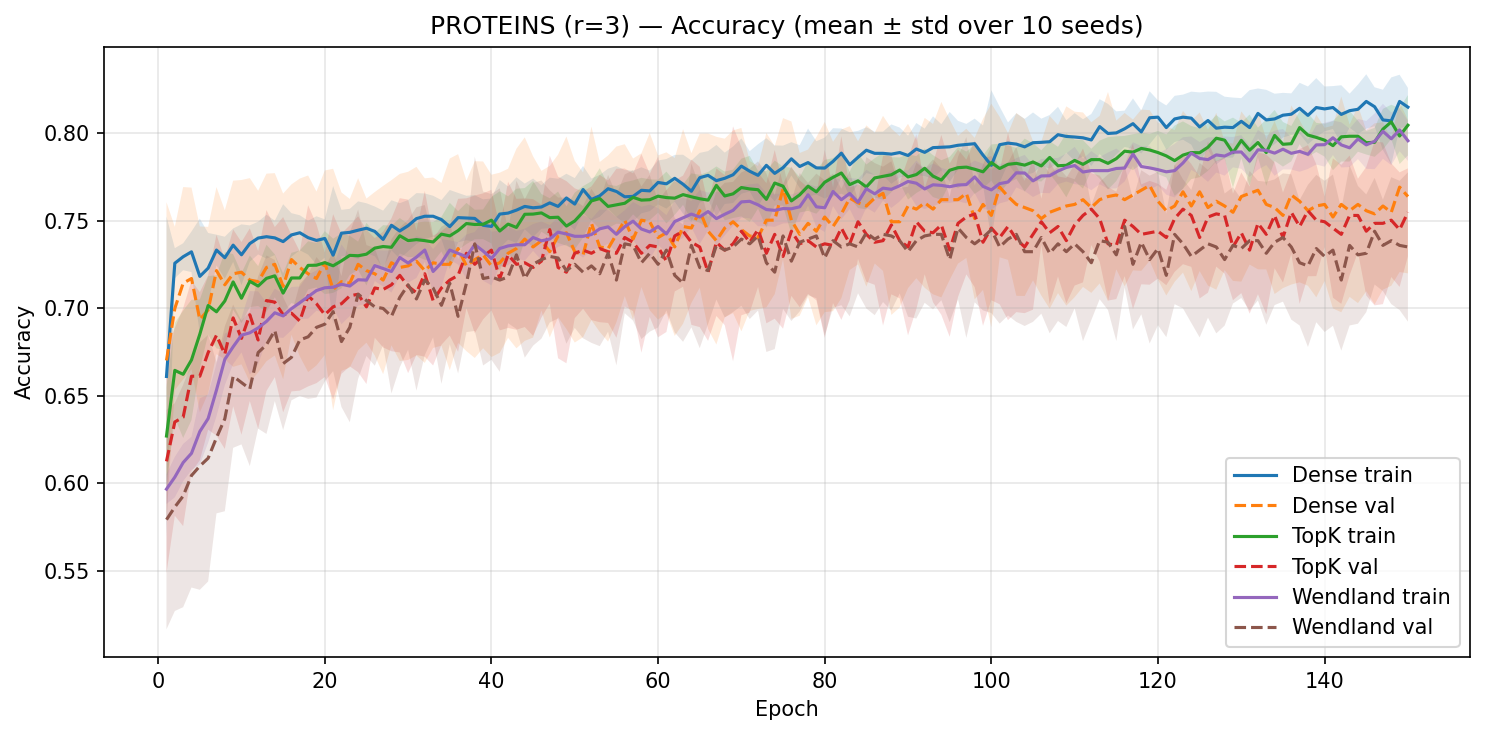

/var/folders/yk/l7sh5fjx7vdbxl9_0_vkmppc001_xm/T/ipykernel_80441/2366332782.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(final_test.values(), labels=final_test.keys(), showmeans=True)


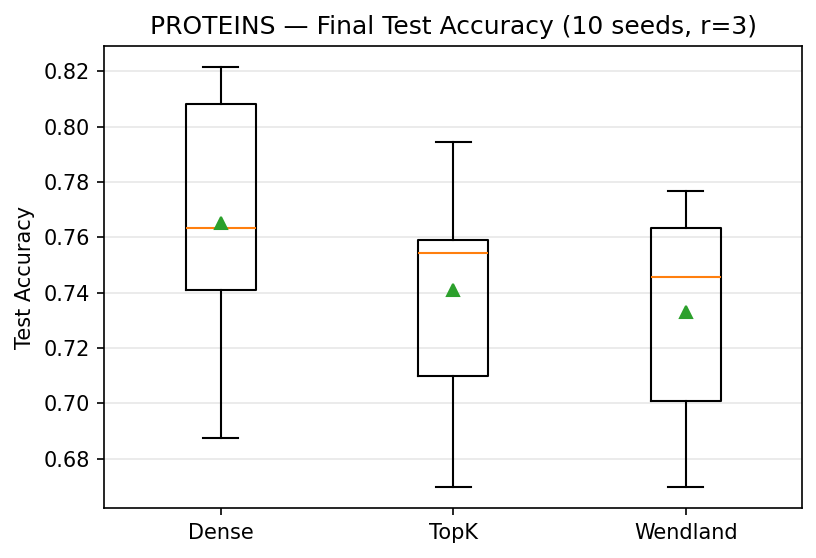

Dense: mean=0.7652, std=0.0454
TopK: mean=0.7411, std=0.0372
Wendland: mean=0.7330, std=0.0376


In [20]:
# ------------------------
# Main experiment
# ------------------------
def run_proteins_10seeds(radius=3):
    cfg = TrainCfg()

    transform = OneHotDegree(max_degree=50)
    dataset = TUDataset(root="data/TU", name="PROTEINS",
                        use_node_attr=True,
                        transform=transform)

    print("Dataset:", dataset)
    print("Graphs:", len(dataset))

    curves_by_model = {"Dense": [], "TopK": [], "Wendland": []}
    final_test = {"Dense": [], "TopK": [], "Wendland": []}

    for seed in range(10):
        print("\nSeed:", seed)
        set_seed(seed)

        train_ds, val_ds, test_ds = split_dataset(dataset, seed)
        train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=cfg.batch_size)
        test_loader = DataLoader(test_ds, batch_size=cfg.batch_size)

        models = {
            "Dense": DensePairNet(dataset.num_node_features, 128,
                                  dataset.num_classes, num_layers=3),
            "TopK": TopKPairNet(dataset.num_node_features, 128,
                                dataset.num_classes,
                                radius_for_budget=radius,
                                num_layers=3),
            "Wendland": WendlandPairNet(dataset.num_node_features, 128,
                                        dataset.num_classes,
                                        radius=radius,
                                        num_layers=3),
        }

        for name, model in models.items():
            model, hist = train_one(model, train_loader, val_loader, cfg)
            test_acc = eval_acc(model, test_loader, cfg.device)

            curves_by_model[name].append(hist)
            final_test[name].append(test_acc)

            print(f"{name} test acc: {test_acc:.4f}")

    # Curves
    plot_mean_std(curves_by_model,
                  "train_loss", "val_loss",
                  "Cross-Entropy Loss",
                  f"PROTEINS (r={radius}) — Loss (mean ± std over 10 seeds)")

    plot_mean_std(curves_by_model,
                  "train_acc", "val_acc",
                  "Accuracy",
                  f"PROTEINS (r={radius}) — Accuracy (mean ± std over 10 seeds)")

    # Boxplot
    plt.figure(figsize=(6,4), dpi=150)
    plt.boxplot(final_test.values(), labels=final_test.keys(), showmeans=True)
    plt.ylabel("Test Accuracy")
    plt.title(f"PROTEINS — Final Test Accuracy (10 seeds, r={radius})")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    for k, v in final_test.items():
        print(f"{k}: mean={np.mean(v):.4f}, std={np.std(v):.4f}")


# Run
if __name__ == "__main__":
    run_proteins_10seeds(radius=3)

In [21]:
dataset = TUDataset(root="data/TU", name="PROTEINS", use_node_attr=True)

print("num_node_features:", dataset.num_node_features)

num_node_features: 4


In [22]:
print(dataset)
print("num_node_features:", dataset.num_node_features)

PROTEINS(1113)
num_node_features: 4
